In [1]:
!pip install torch torchvision torchmetrics opencv-python tqdm

from google.colab import drive
drive.mount('/content/drive')

!cp -r "/content/drive/MyDrive/Colab Notebooks/datasets" /content/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.0 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50
from PIL import Image

IGNORE_INDEX = 255
NUM_CLASSES = 6

RUGD_COLOR_MAP = {
    (0, 0, 0): 255,

    (108, 64, 20): 1,
    (255, 229, 204): 1,
    (64, 64, 64): 1,

    (0, 102, 0): 2,
    (0, 255, 0): 2,

    (255, 0, 0): 3,
    (102, 0, 0): 3,

    (0, 0, 255): 4,
    (0, 128, 255): 5,
}

In [3]:
def rugd_color_to_label(mask_img, color_map):
    mask = np.array(mask_img)
    label = np.ones(mask.shape[:2], dtype=np.uint8) * IGNORE_INDEX

    for color, class_id in color_map.items():
        matches = np.all(mask == np.array(color), axis=-1)
        label[matches] = class_id

    return label

In [4]:
img_transform = transforms.Compose([
    transforms.Resize((512, 1024)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

label_resize = transforms.Resize(
    (512, 1024),
    interpolation=transforms.InterpolationMode.NEAREST
)
label_transform = transforms.Resize(
    (512, 1024),
    interpolation=transforms.InterpolationMode.NEAREST
)

In [5]:
class RUGDDataset(Dataset):
    def __init__(self, img_dir, ann_dir, color_map, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.color_map = color_map
        self.transform = transform

        imgs = {os.path.splitext(f)[0]: f for f in os.listdir(img_dir)}
        anns = {os.path.splitext(f)[0]: f for f in os.listdir(ann_dir)}

        self.keys = sorted(set(imgs.keys()) & set(anns.keys()))
        self.img_map = imgs
        self.ann_map = anns

        print(f"RUGD: {len(self.keys)} valid pairs")

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]

        image = Image.open(
            os.path.join(self.img_dir, self.img_map[key])
        ).convert("RGB")

        mask = Image.open(
            os.path.join(self.ann_dir, self.ann_map[key])
        ).convert("RGB")

        mask = label_resize(mask)
        label = rugd_color_to_label(mask, self.color_map)

        if self.transform:
            image = self.transform(image)

        return image, torch.from_numpy(label).long()

In [6]:
CITYSCAPES_MAP = {7:0, 8:0, 21:1, 23:2, 10:3}

def remap_cityscapes(label_img):
    label = np.array(label_img)
    out = np.ones_like(label) * IGNORE_INDEX
    for k, v in CITYSCAPES_MAP.items():
        out[label == k] = v
    return torch.from_numpy(out).long()

class CityscapesSimple(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform

        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.endswith("_leftImg8bit.png")
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)

        label_name = img_name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelIds.png"
        )
        ann_path = os.path.join(self.ann_dir, label_name)

        image = Image.open(img_path).convert("RGB")
        label_img = Image.open(ann_path)

        label_img = label_transform(label_img)
        label = remap_cityscapes(label_img)

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
# ---- ROOTS ----
CITYSCAPES_ROOT = "/content/datasets/cityscapes"
RUGD_ROOT       = "/content/datasets/rugd"

city_train = CityscapesSimple(
    img_dir=f"{CITYSCAPES_ROOT}/leftImg8bit_train",
    ann_dir=f"{CITYSCAPES_ROOT}/gtFine",
    transform=img_transform
)

rugd_test = RUGDDataset(
    img_dir=f"{RUGD_ROOT}/frames_with_annotations",
    ann_dir=f"{RUGD_ROOT}/annotations",
    color_map=RUGD_COLOR_MAP,
    transform=img_transform
)

print("Cityscapes samples:", len(city_train))
print("RUGD samples:", len(rugd_test))

RUGD: 400 valid pairs
Cityscapes samples: 359
RUGD samples: 400


In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 2
NUM_WORKERS = 2

city_train_loader = DataLoader(
    city_train,
    batch_size=2,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True   # 🔥 THIS FIXES IT
)

rugd_test_loader = DataLoader(
    rugd_test,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [9]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = deeplabv3_resnet50(
    weights="DEFAULT"
)

model.classifier[4] = nn.Conv2d(
    in_channels=256,
    out_channels=NUM_CLASSES,
    kernel_size=1
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 129MB/s]


In [10]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)["out"]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
EPOCHS = 5

for epoch in range(EPOCHS):
    loss = train_one_epoch(
        model,
        city_train_loader,
        optimizer,
        criterion
    )
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f}")

Epoch 1/5 - Loss: 0.2388
Epoch 2/5 - Loss: 0.0562
Epoch 3/5 - Loss: 0.0335
Epoch 4/5 - Loss: 0.0236
Epoch 5/5 - Loss: 0.0176


In [13]:
import numpy as np

def compute_iou(pred, target, num_classes):
    ious = []

    pred = pred.flatten()
    target = target.flatten()

    for cls in range(1, num_classes):  # skip 0
        pred_inds = pred == cls
        target_inds = target == cls

        intersection = (pred_inds & target_inds).sum()
        union = (pred_inds | target_inds).sum()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)

    return ious

In [14]:
def evaluate_miou(model, loader, num_classes):
    model.eval()
    all_ious = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)["out"]
            preds = torch.argmax(outputs, dim=1)

            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()

            for p, l in zip(preds, labels):
                ious = compute_iou(p, l, num_classes)
                all_ious.append(ious)

    all_ious = np.array(all_ious)
    miou = np.nanmean(all_ious)

    return miou

In [15]:
baseline_miou = evaluate_miou(
    model,
    rugd_test_loader,
    NUM_CLASSES
)

print(f"Baseline Cityscapes → RUGD mIoU: {baseline_miou:.4f}")


Baseline Cityscapes → RUGD mIoU: 0.0015


In [16]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/baseline_cityscapes.pth")

In [17]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

model.eval()
images, labels = next(iter(rugd_test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    preds = model(images)["out"].argmax(1)

print("Pred unique:", torch.unique(preds.cpu()))
print("GT unique:", torch.unique(labels))


Using device: cuda
Pred unique: tensor([0, 1, 2])
GT unique: tensor([  1,   2,   4,   5, 255])


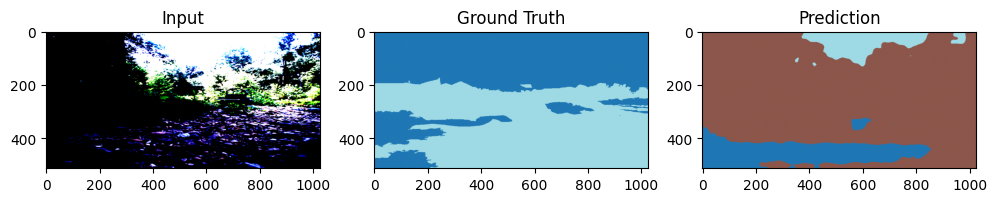

In [18]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(rugd_test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    preds = model(images)["out"].argmax(1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0].cpu().permute(1,2,0))
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(labels[0].cpu(), cmap="tab20")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(preds[0].cpu(), cmap="tab20")
plt.title("Prediction")

plt.show()


STEP 4 IN METHODOLGY

In [19]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch

# -------------------------
# 1. Few-shot split
# -------------------------
FEW_SHOT = 100   # change if needed

rugd_fewshot = Subset(
    rugd_test,               # reuse same dataset
    list(range(FEW_SHOT))
)

rugd_fewshot_loader = DataLoader(
    rugd_fewshot,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# -------------------------
# 2. Freeze backbone
# -------------------------
for p in model.backbone.parameters():
    p.requires_grad = False

# -------------------------
# 3. Class weights (from few-shot)
# -------------------------
def compute_class_weights(loader, num_classes):
    counts = torch.zeros(num_classes)

    for _, labels in loader:
        labels = labels.view(-1)
        for c in range(num_classes):
            counts[c] += (labels == c).sum()

    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return weights

class_weights = compute_class_weights(
    rugd_fewshot_loader,
    NUM_CLASSES
)

# ignore water class
class_weights[5] = 0.0
class_weights = class_weights.to(device)

# -------------------------
# 4. Loss + optimizer (HEAD ONLY)
# -------------------------
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=IGNORE_INDEX
)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

In [20]:
FINE_TUNE_EPOCHS = 5

for epoch in range(FINE_TUNE_EPOCHS):
    loss = train_one_epoch(
        model,
        rugd_fewshot_loader,
        optimizer,
        criterion
    )
    print(f"Epoch {epoch+1}/{FINE_TUNE_EPOCHS} | Loss: {loss:.4f}")


Epoch 1/5 | Loss: 2.0088
Epoch 2/5 | Loss: 0.6282
Epoch 3/5 | Loss: 0.3342
Epoch 4/5 | Loss: 0.2274
Epoch 5/5 | Loss: 0.1757


In [21]:
adapted_miou = evaluate_miou(
    model,
    rugd_test_loader,
    NUM_CLASSES
)

print(f"Adapted City → RUGD mIoU (few-shot): {adapted_miou:.4f}")

Adapted City → RUGD mIoU (few-shot): 0.2480


In [22]:
model.eval()

images, labels = next(iter(rugd_test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)["out"]

preds = outputs.argmax(1).cpu()

print("Pred unique:", torch.unique(preds))
print("GT unique:", torch.unique(labels))

Pred unique: tensor([0, 1, 2, 3, 4])
GT unique: tensor([  1,   2,   4,   5, 255])


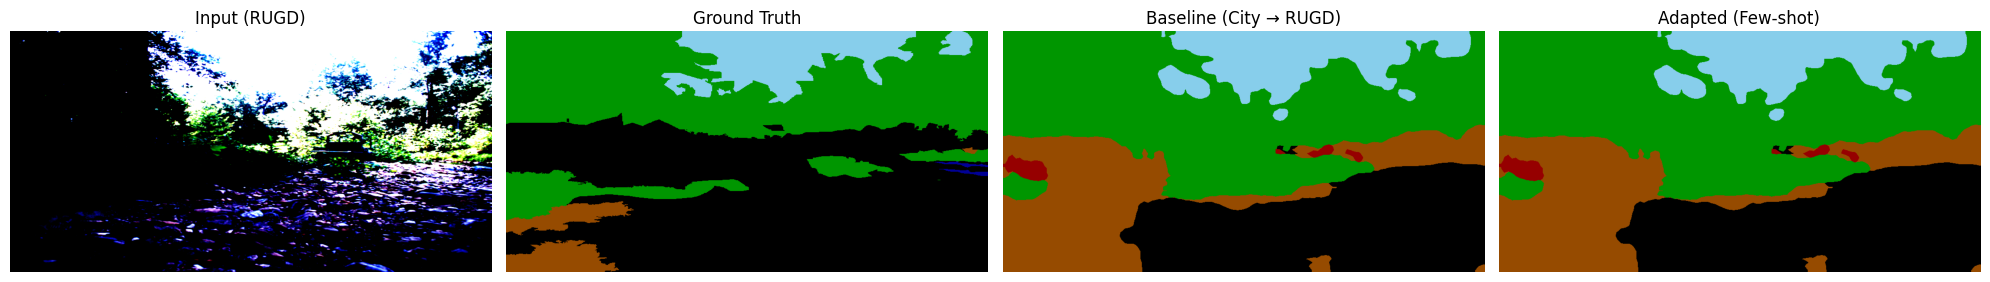

In [23]:
import matplotlib.pyplot as plt
import numpy as np

RUGD_COLORS = {
    0: (0, 0, 0),        # ignore
    1: (150, 75, 0),     # drivable
    2: (0, 150, 0),     # vegetation
    3: (150, 0, 0),     # obstacle
    4: (135, 206, 235), # sky
    5: (0, 0, 150),     # water
}

def decode_mask(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for k, v in RUGD_COLORS.items():
        rgb[mask == k] = v
    return rgb
model.eval()

images, labels = next(iter(rugd_test_loader))
images = images.to(device)

# Save GT
gt = labels[0].cpu().numpy()

model.eval()

with torch.no_grad():
    base_out = model(images)["out"]

base_pred = base_out.argmax(1)[0].cpu().numpy()

with torch.no_grad():
    adapted_out = model(images)["out"]

adapted_pred = adapted_out.argmax(1)[0].cpu().numpy()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(images[0].permute(1, 2, 0).cpu())
axs[0].set_title("Input (RUGD)")
axs[0].axis("off")

axs[1].imshow(decode_mask(gt))
axs[1].set_title("Ground Truth")
axs[1].axis("off")

axs[2].imshow(decode_mask(base_pred))
axs[2].set_title("Baseline (City → RUGD)")
axs[2].axis("off")

axs[3].imshow(decode_mask(adapted_pred))
axs[3].set_title("Adapted (Few-shot)")
axs[3].axis("off")

plt.tight_layout()
plt.show()


STEP 5

In [24]:
import torch.nn.functional as F

def sobel_edges(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)

    x = x * std + mean  # de-normalize to [0,1]

    gray = 0.299*x[:,0] + 0.587*x[:,1] + 0.114*x[:,2]
    gray = gray.unsqueeze(1)

    sobel_x = torch.tensor(
        [[[-1, 0, 1],
          [-2, 0, 2],
          [-1, 0, 1]]],
        dtype=torch.float32,
        device=x.device
    ).unsqueeze(0)

    sobel_y = torch.tensor(
        [[[-1, -2, -1],
          [ 0,  0,  0],
          [ 1,  2,  1]]],
        dtype=torch.float32,
        device=x.device
    ).unsqueeze(0)

    gx = F.conv2d(gray, sobel_x, padding=1)
    gy = F.conv2d(gray, sobel_y, padding=1)

    edges = torch.sqrt(gx**2 + gy**2)
    edges = edges / (edges.max() + 1e-6)  # normalize

    return edges

In [25]:
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn

multi_model = deeplabv3_resnet50(
    weights="DEFAULT"
)

multi_model.classifier[4] = nn.Conv2d(
    256, NUM_CLASSES, kernel_size=1
)

multi_model.load_state_dict(model.state_dict(), strict=False)

# Replace first conv (RGB → RGB+Edge)
old_conv = multi_model.backbone.conv1
multi_model.backbone.conv1 = nn.Conv2d(
    4, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Init weights
multi_model.backbone.conv1.weight.data[:, :3] = old_conv.weight.data
multi_model.backbone.conv1.weight.data[:, 3:] = old_conv.weight.data.mean(dim=1, keepdim=True)

multi_model = multi_model.to(device)

In [26]:
state = model.state_dict()
multi_state = multi_model.state_dict()

for k in state:
    if k in multi_state and state[k].shape == multi_state[k].shape:
        multi_state[k] = state[k]

multi_model.load_state_dict(multi_state)

for name, p in multi_model.backbone.named_parameters():
    if "conv1" in name or "bn1" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False

In [27]:
def train_one_epoch_multimodal(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        edges = sobel_edges(images)
        inputs = torch.cat([images, edges], dim=1)

        optimizer.zero_grad()
        outputs = model(inputs)["out"]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [28]:
optimizer = torch.optim.Adam(
    multi_model.classifier.parameters(),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=IGNORE_INDEX
)

In [29]:
MULTI_EPOCHS = 5

for epoch in range(MULTI_EPOCHS):
    loss = train_one_epoch_multimodal(
        multi_model,
        rugd_fewshot_loader,
        optimizer,
        criterion
    )
    print(f"[Step 5] Epoch {epoch+1}/{MULTI_EPOCHS} | Loss: {loss:.4f}")

[Step 5] Epoch 1/5 | Loss: 0.1461
[Step 5] Epoch 2/5 | Loss: 0.1071
[Step 5] Epoch 3/5 | Loss: 0.0925
[Step 5] Epoch 4/5 | Loss: 0.0785
[Step 5] Epoch 5/5 | Loss: 0.0754


In [30]:
def evaluate_miou_multimodal(model, loader, num_classes):
    model.eval()
    all_ious = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            edges = sobel_edges(images)
            inputs = torch.cat([images, edges], dim=1)

            outputs = model(inputs)["out"]
            preds = torch.argmax(outputs, dim=1)

            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()

            for p, l in zip(preds, labels):
                ious = compute_iou(p, l, num_classes)
                all_ious.append(ious)

    return np.nanmean(np.array(all_ious))

In [31]:
multi_miou = evaluate_miou_multimodal(
    multi_model,
    rugd_test_loader,
    NUM_CLASSES
)

print(f"Multimodal Adapted mIoU: {multi_miou:.4f}")

Multimodal Adapted mIoU: 0.2518


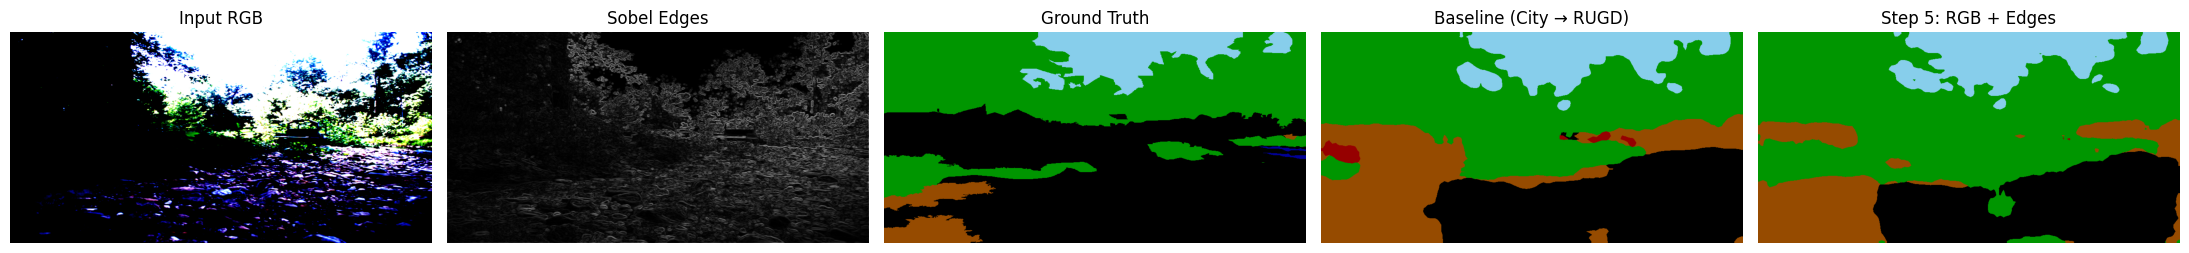

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Color decoding (same as yours)
# -------------------------
RUGD_COLORS = {
    0: (0, 0, 0),        # ignore
    1: (150, 75, 0),     # drivable
    2: (0, 150, 0),     # vegetation
    3: (150, 0, 0),     # obstacle
    4: (135, 206, 235), # sky
    5: (0, 0, 150),     # water
}

def decode_mask(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for k, v in RUGD_COLORS.items():
        rgb[mask == k] = v
    return rgb


# -------------------------
# Get ONE sample from RUGD
# -------------------------
model.eval()
multi_model.eval()

images, labels = next(iter(rugd_test_loader))
images = images.to(device)

# Ground truth
gt = labels[0].cpu().numpy()

# -------------------------
# Baseline prediction (no edges)
# -------------------------
with torch.no_grad():
    base_out = model(images)["out"]
base_pred = base_out.argmax(1)[0].cpu().numpy()

# -------------------------
# Step 5 multimodal prediction (RGB + edges)
# -------------------------
with torch.no_grad():
    edges = sobel_edges(images)
    multi_inputs = torch.cat([images, edges], dim=1)
    multi_out = multi_model(multi_inputs)["out"]

multi_pred = multi_out.argmax(1)[0].cpu().numpy()

# -------------------------
# Visualization
# -------------------------
fig, axs = plt.subplots(1, 5, figsize=(22, 5))

axs[0].imshow(images[0].cpu().permute(1, 2, 0))
axs[0].set_title("Input RGB")
axs[0].axis("off")

axs[1].imshow(edges[0, 0].cpu(), cmap="gray")
axs[1].set_title("Sobel Edges")
axs[1].axis("off")

axs[2].imshow(decode_mask(gt))
axs[2].set_title("Ground Truth")
axs[2].axis("off")

axs[3].imshow(decode_mask(base_pred))
axs[3].set_title("Baseline (City → RUGD)")
axs[3].axis("off")

axs[4].imshow(decode_mask(multi_pred))
axs[4].set_title("Step 5: RGB + Edges")
axs[4].axis("off")

plt.tight_layout()
plt.show()

STEP 6: STEP4+STEP5 TGT NOW

In [33]:
def grayscale_channel(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
    x = x * std + mean

    gray = 0.299*x[:,0] + 0.587*x[:,1] + 0.114*x[:,2]
    return gray.unsqueeze(1)


from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn

multi_model = deeplabv3_resnet50(weights="DEFAULT")

multi_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, 1)

# Modify first conv (3 → 4 channels)
old_conv = multi_model.backbone.conv1
multi_model.backbone.conv1 = nn.Conv2d(
    4, 64, kernel_size=7, stride=2, padding=3, bias=False
)

# Init weights
with torch.no_grad():
    multi_model.backbone.conv1.weight[:, :3] = old_conv.weight
    multi_model.backbone.conv1.weight[:, 3]  = old_conv.weight.mean(dim=1)

multi_model = multi_model.to(device)

state = model.state_dict()  # model from Step 4
multi_state = multi_model.state_dict()

for k in state:
    if k in multi_state and state[k].shape == multi_state[k].shape:
        multi_state[k] = state[k]

multi_model.load_state_dict(multi_state)

for name, p in multi_model.named_parameters():
    if (
        "classifier" in name or
        "aspp" in name or
        "conv1" in name or
        "bn1" in name
    ):
        p.requires_grad = True
    else:
        p.requires_grad = False

from torch.utils.data import ConcatDataset

mixed_train = ConcatDataset([
    city_train,
    rugd_fewshot
])

mixed_loader = DataLoader(
    mixed_train,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    drop_last=True
)


def train_one_epoch_tgt(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        gray = grayscale_channel(images)
        inputs = torch.cat([images, gray], dim=1)

        optimizer.zero_grad()
        outputs = model(inputs)["out"]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, multi_model.parameters()),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=IGNORE_INDEX
)

In [34]:
EPOCHS = 6

for epoch in range(EPOCHS):
    loss = train_one_epoch_tgt(
        multi_model,
        mixed_loader,
        optimizer,
        criterion
    )
    print(f"[Step 6 - TGT] Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f}")

[Step 6 - TGT] Epoch 1/6 | Loss: 0.0747
[Step 6 - TGT] Epoch 2/6 | Loss: 0.0218
[Step 6 - TGT] Epoch 3/6 | Loss: 0.0163
[Step 6 - TGT] Epoch 4/6 | Loss: 0.0083
[Step 6 - TGT] Epoch 5/6 | Loss: 0.0201
[Step 6 - TGT] Epoch 6/6 | Loss: 0.0128


In [35]:
def evaluate_miou_tgt(model, loader, num_classes):
    model.eval()
    all_ious = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            gray = grayscale_channel(images)
            inputs = torch.cat([images, gray], dim=1)

            preds = model(inputs)["out"].argmax(1)

            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()

            for p, l in zip(preds, labels):
                ious = compute_iou(p, l, num_classes)
                all_ious.append(ious)

    return np.nanmean(np.array(all_ious))

tgt_miou = evaluate_miou_tgt(
    multi_model,
    rugd_test_loader,
    NUM_CLASSES
)

print(f"Step 6 TGT mIoU: {tgt_miou:.4f}")

Step 6 TGT mIoU: 0.2818


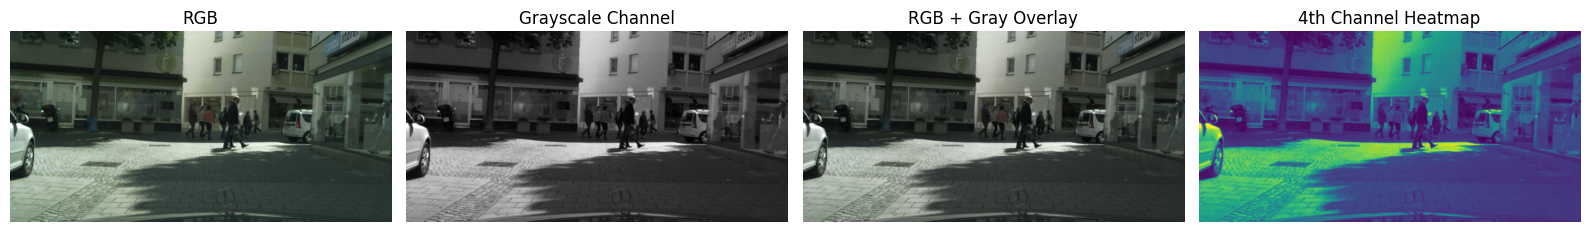

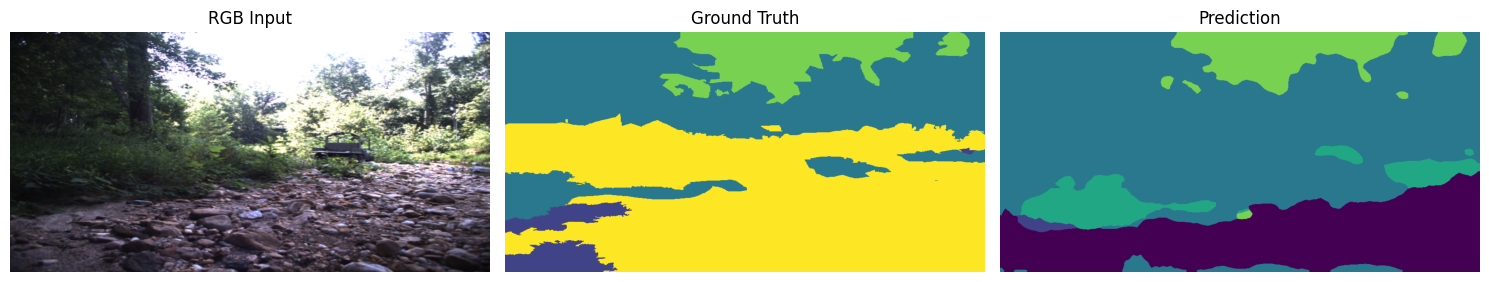

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Denormalize helper (same stats you used)
def denormalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
    return x * std + mean


def visualize_rgb_gray(images, idx=0):
    """
    images: Tensor [B,3,H,W] normalized
    idx: which image in batch to visualize
    """
    with torch.no_grad():
        img = images[idx:idx+1]
        img_dn = denormalize(img).clamp(0, 1)

        gray = grayscale_channel(images)[idx, 0]

    rgb = img_dn[0].permute(1, 2, 0).cpu().numpy()
    gray_np = gray.cpu().numpy()

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    axs[0].imshow(rgb)
    axs[0].set_title("RGB")
    axs[0].axis("off")

    axs[1].imshow(gray_np, cmap="gray")
    axs[1].set_title("Grayscale Channel")
    axs[1].axis("off")

    axs[2].imshow(rgb)
    axs[2].imshow(gray_np, cmap="gray", alpha=0.5)
    axs[2].set_title("RGB + Gray Overlay")
    axs[2].axis("off")

    axs[3].imshow(gray_np, cmap="viridis")
    axs[3].set_title("4th Channel Heatmap")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

images, labels = next(iter(mixed_loader))
visualize_rgb_gray(images)

def visualize_prediction(model, images, labels, num_classes, idx=0):
    model.eval()
    with torch.no_grad():
        images = images.to(device)
        labels = labels.to(device)

        gray = grayscale_channel(images)
        inputs = torch.cat([images, gray], dim=1)

        outputs = model(inputs)["out"]
        preds = outputs.argmax(1)

        img_dn = denormalize(images[idx:idx+1]).clamp(0, 1)

    rgb = img_dn[0].permute(1, 2, 0).cpu().numpy()
    gt = labels[idx].cpu().numpy()
    pred = preds[idx].cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(rgb)
    axs[0].set_title("RGB Input")
    axs[0].axis("off")

    axs[1].imshow(gt, vmin=0, vmax=num_classes-1)
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(pred, vmin=0, vmax=num_classes-1)
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

images, labels = next(iter(rugd_test_loader))
visualize_prediction(
    multi_model,
    images,
    labels,
    NUM_CLASSES
)

CHANGE GEARS SINCE STEP 5 DID NOT SHOW MUCH IMPROVEMENT

In [ ]:
import os
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

class TargetOnlyDataset(Dataset):
    def __init__(self, image_dir, transform):
        self.image_paths = sorted(
            glob.glob(os.path.join(image_dir, "*.png"))  # change to *.jpg if needed
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)
        return img

target_loader = DataLoader(
    TargetOnlyDataset(
        image_dir="/content/datasets/rugd/frames_with_annotations",
        transform=img_transform
    ),
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

imgs = next(iter(target_loader))
print(imgs.shape)

for p in model.backbone.parameters():
    p.requires_grad = False

def get_pseudo_labels(logits, threshold=0.9):
    probs = torch.softmax(logits, dim=1)
    conf, pseudo = torch.max(probs, dim=1)

    pseudo[conf < threshold] = IGNORE_INDEX
    return pseudo
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

PSEUDO_EPOCHS = 2   # KEEP SMALL
CONF_THRESH = 0.9  # HIGH CONF ONLY

model.train()

for epoch in range(PSEUDO_EPOCHS):
    total_loss = 0
    used_pixels = 0

    for images in target_loader:
        images = images.to(device)

        with torch.no_grad():
            logits = model(images)["out"]
            pseudo_labels = get_pseudo_labels(logits, CONF_THRESH)

        if (pseudo_labels != IGNORE_INDEX).sum() < 1000:
            continue  # skip weak batches

        optimizer.zero_grad()
        outputs = model(images)["out"]
        loss = criterion(outputs, pseudo_labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        used_pixels += (pseudo_labels != IGNORE_INDEX).sum().item()

    print(f"[Step 5] Epoch {epoch+1}/{PSEUDO_EPOCHS} | Loss: {total_loss:.4f} | Used px: {used_pixels}")

    step5_miou = evaluate_miou(
    model,
    rugd_test_loader,
    NUM_CLASSES
)

print(f"Step 5 (Self-Training) mIoU: {step5_miou:.4f}")

torch.Size([2, 3, 512, 1024])
[Step 5] Epoch 1/2 | Loss: 0.0816 | Used px: 234969573
[Step 5] Epoch 2/2 | Loss: 0.0044 | Used px: 235818453
Step 5 (Self-Training) mIoU: 0.1525
